# Lista 02 - Estatística

**Questão 01 - Usando o mesmo portfolio da sua lista anterior, normalize os retornos logarítmicos,( z-score). O que ele significa?**

In [ ]:
#IMPORTANDO TODAS AS FERRAMENTAS/EXTENSÕES QUE PROVAVELMENTE VOU USAR
import pandas as pd 
import plotly.graph_objects as go 
import numpy as np 
#COPIANDO CODIGO DA LISTA 1 PARA CHEGAR NO PORTFOLIO
df=pd.read_excel( #chama-se de df o dataframe que vamos usar ao longo do exercicio, depois vamos le-lo
    r"C:\Users\masil\Downloads\quant_lista1.ms.xlsx", 
    header=3, # os "titulos" das colunas estão na 4 linha, como no python a gente comeca a contar na linha 0, colocamos o 3 
    skiprows=[4], # linha 5 tem umas informacoes a mais do ano passado, que esta NA 
    index_col=0 # coluna 0, que no excel é a A, referente a data fica indexada
    )    
df.index = pd.to_datetime(df.index) #escrevendo coluna de datas no formato de data, ja tava no caso 
df.columns=["ABEV3", "EMBR3","LREN3","PETR3","VALE3","IBOV"]
df = df.apply(pd.to_numeric, errors='coerce')
ativos = ["ABEV3", "EMBR3", "LREN3", "PETR3", "VALE3"]
pesos = {
    "ABEV3":0.09,
    "EMBR3":0.25,
    "LREN3":0.11,
    "PETR3":0.20,
    "VALE3":0.35
}
def calcular_retorno_simples(col):
        return  col / col.shift(1) - 1
df_retorno_simples = df.apply(calcular_retorno_simples) # retorno simples de cada ativo
pesos_series=pd.Series(pesos)
retorno_diario_portfolio=df_retorno_simples[ativos].dot(pesos_series) 
#COMECANDO EXERCICIO LISTA 2 
log_retorno_portfolio = np.log(1+retorno_diario_portfolio) # formula para calcular log retorno a partir do retorno simples
log_retorno_portfolio=log_retorno_portfolio.dropna() # dropei os nas pq estava dando problema nos codigos subsequentes,
                                                       # mas caso necessario essas informacoes ainda estao no df geral
data=log_retorno_portfolio.index
media_portfolio=log_retorno_portfolio.mean()
desviopadrao_portfolio=log_retorno_portfolio.std()
zscore=(log_retorno_portfolio-media_portfolio)/desviopadrao_portfolio # vai aplicando essa formula para todas as entraas (datas) do log 
fig=go.Figure()
fig.add_trace(go.Scatter(
        x=data,
        y=zscore,
        mode="lines",
        name="zscore",
        marker_color="gold"
        ))
fig.update_layout(title="Zscore do portfólio")
fig.show()
log_retorno_portfolio.to_excel("logretorno", index=False)




O z-scoore calcula quantos devios padrão a variável "está longe da média". Nesse caso, estamos calculando o quanto o retorno logarítimo em cada dia desvia da média geral do retorno logarítimico do portfólio. O ponto de maior detaque no gráfico do z-score acontece nos meses de fevereiro março e abril de 2025, os dados desviaram muito da média, com z score chegando até +9 e -11. Isso provavelmente foi gerado por causa da pandemia de covid 19.

**Questão 02 - Com os retornos normalizados, plote um histograma deles. Também adicione uma curva de gauss e 3 curvas de t-student com n = 5,10 e 50. O que difere a t-student da curva gaussiana?**

In [3]:
from scipy.stats import norm, t
#HISTOGRAMA com z score normalizado
fig=go.Figure()
fig.add_trace(go.Histogram(
    x=zscore,
    histnorm="probability density",
    name="Histograma",
    opacity=0.8,
    marker_color="salmon"
))
#CURVA DE GAUSS (FDP DA NORMAL)
eixo_x = np.linspace(-5, 5, 500) # a maioria dos zscores estão distribuidos entre 5 e -5
                                 # quando eu coloquei apenas o z score como eixo x criou varias linhas deu errado 
gauss = norm.pdf(eixo_x, loc=0, scale=1) # esse loc e scale representam os índices do z score, que é média 0 e devio padrão 1 N(0,1)
fig.add_trace(go.Scatter(
    x=eixo_x,
    y=gauss,
    mode="lines",
    name="Curva de Gauss",
    line=dict(color="crimson", width=3) # width eh a grossura linha
))
#T-STUDENT
def plotar_tstudent(n,cor): #defini dependendo da cor tambem para cada curva para um n diferente ter una cor diferrente 
    tstudent = t.pdf(eixo_x, df=n, loc=0, scale=1)
    fig.add_trace(go.Scatter(
        x=eixo_x, 
        y=tstudent, 
        mode="lines",
        name=f"T-Student (n={n})", # f pra o n ser o mesmo que eu coloco na hora de aplicar a funcao
        line=dict(color= cor, width=1)
            ))
plotar_tstudent(5,"darkcyan")
plotar_tstudent(10,"aquamarine")
plotar_tstudent(50,"springgreen")
fig.update_layout(title="Histograma, curva de gauss e t student")
fig.show()

Tanto a curva gaussiana quanto a tstudent aparecem como forma de tentar aproximar a distribuiçaõ da probabilidade de variáveis, nesse caso, dos log retornos normalizados do portfólio. A curva gaussiana descreve uma função de distribuição de probabilidade normal com desvio padrão conhecido. Normalmente, não sabemos o desvio padrão populacional, porque, é impossível saber a volatilidade dos ativos no futuro e, no nosso caso, não temos nem todos dados do passado de todos os log retornos dos ativos que compõe nosso portfólio (só a partir de 2017) Mas, para montar essa gausiana, interpretamos os log retornos do portifolio no período temporal da base de dados (2017 a 2026) como população inteira. Como fizemos a normalização, usando o zscore dos log retornos do portfólio, a gaussiana usa os desvios padrão como 1 (e média 0). 

Enquanto isso, a t student é usada interpretando os dados como amostras, pensando que não  sabemos a volatilidade específica (desvio padrão) dos nossos ativos. Assim, a gaussiana se diferencia da tstudent, pois na tstudent, usamos uma amostra específica, no caso log retornos de dias específicos, e estimamos, a partir disso, uma função de distribuição de probabilidade. Por fazer essa estimativa, a fórmula do desvio padrão atribui maior probabilidade a eventos extremos, em comparação com a gaussiana. Isso aparece no gráfico da fdp com caldas mais gordas/pesadas.

**Questão 03 - Considerando que os log retornos são normais, calcule a probabilidade de termos um retorno acima de 3%**

In [4]:
#Considerando que os log-retornos são normais, irmemos calcular usando uma fdp N~(média portfólio, desvio padrão do portfólio)
# para os log retornos.
print(media_portfolio)
print(desviopadrao_portfolio)
#transformando o retorno de 3% em log retorno, já que os parâmetros estão usando log
ln3=np.log(1+0.03)
print(ln3)
#calcular o z desse log retorno
z3=(ln3-media_portfolio)/desviopadrao_portfolio
print(z3)
#manualmente, procura se o valor na tabela da nromal padrao 
#e chega no valor aproximado de 0.9545.
#esse resultado é a probabilidade dos retornos darem a baixo de 3%. 
#como queremos acima de 3%, fazemos 1-0.945, que dá aproximadamente 4,55%
#testando se a conta "na mao" deu certo, usando o python
prob=norm.sf(z3) #a função sf já faz a conta do 1 - probabilidade de ser menor 
print(prob)


0.0009210503166497355
0.01693585648339432
0.02955880224154443
1.6909538618831668
0.04542280746751149


**Questão 04 - Plote a PDF e a CDF dos log-retornos do seu portfólio.**

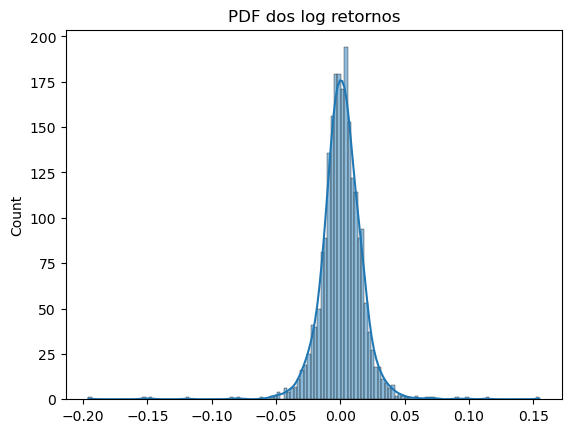

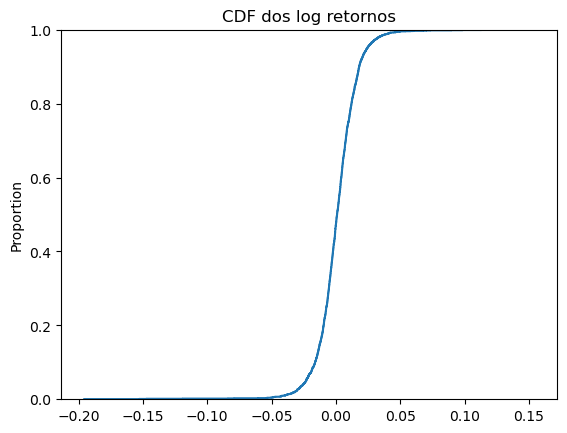

In [5]:
import seaborn as sbs
import scipy as scp
import matplotlib.pyplot as plt
sbs.histplot(data=log_retorno_portfolio,kde=True)
plt.title("PDF dos log retornos")
plt.show()
sbs.ecdfplot(data=log_retorno_portfolio)
plt.title("CDF dos log retornos")
plt.show()

**Questão 05 - Encontre kurtosis e skewness do retornos logarítmicos do seu portfólio. Qual o significado dessas medidas? Quais são os valores para uma normal padrão e qual o significado da diferença desses valores para o seu portfólio e para uma normal padrão?**


In [7]:
from scipy.stats import skew,kurtosis
pskew=skew(log_retorno_portfolio)
pkurtosis=kurtosis(log_retorno_portfolio)
print(pskew)
print(pkurtosis)

-0.9422138858883528
20.02395828679609


O skewnees mostra a simetria da função. Uma função perfeitamente simétrica, como é o caso da normal padrão, é 0. Se uma função tiver simetria mais próximo de +1, sua pdf tem uma calda  mais longa para a direita, e -1 para a esquerda. Nesse caso, a simetria de -0.94. Isso significa que tem mais retornos negativos. A kurtosis mostra o quão "achatada" é a função. Uma função normal padrão tem curtose 3. Acima de 3 a função tem um pico alto, como é o caso dos logretornos, que tem curtose de 20. Isso mostra que eventos extremos, como os da pandemia de 2020 acontecem com muito frequência.

**Questão 06 - Considerando que os retornos são normais, calcule o percentil 25% dos retornos e a porcentagem dos dias que teremos retornos negativos**

In [11]:
percentil25 = norm.ppf(0.25, loc=media_portfolio, scale=desviopadrao_portfolio)
print(percentil25)
prob_negativo = norm.cdf(0, loc=media_portfolio, scale=desviopadrao_portfolio)
print(prob_negativo)

-0.01050201129219159
0.4783143614471394


**Questão 07 - O que é o máximo drawdown? Calcule o máximo drawdown do seu portfólio. Interprete o resultado.**


In [13]:
retorno_acumulado = (1 + retorno_diario_portfolio).cumprod()
pico = retorno_acumulado.cummax()
drawdown = (retorno_acumulado - pico) / pico
max_drawdown = drawdown.min()
data_max_dd = drawdown.idxmin()
print(max_drawdown)
print(data_max_dd)


-0.46451079090175346
2020-03-23 00:00:00


O máximo drawdown mede a variação máxima entre os retornos máximo e mínimo de um portfólio, ou seja, a pior perda que um investidor poderia ter no meu portifólio, investindo num ponto alto e vendendo num baixo. Isso é uma medida de volatilidade. A data foi no auge da pandemia do covid 19, o que faz sentido.

**Questão 08 - Teste se os retornos do portfólio são estatisticamente diferentes de zero e do retorno do índice BOVESPA. Qual alpha você utilizaria?**

In [ ]:
from scipy.stats import ttest_1samp, ttest_ind

# TESTE 1: retornos do portfólio são diferentes de zero?
# Hipótese nula H0: média dos retornos = 0
#alpha = 0.05 (5%) -> é os que aparecem normalmente para testes de hipótese

t1, p1 = ttest_1samp(log_retorno_portfolio, 0)
print(f"Teste vs zero — t: {t1:.4f}, p-valor: {p1:.6f}")

# TESTE 2: retornos do portfólio são diferentes dos retornos do IBOV?
#Hipótese nula H0: média dos retornos é igual a do IBOVESPA 
# Alinhamos os índices para garantir mesmas datas
log_retorno_ibov = np.log(1 + df_retorno_simples["IBOV"]).dropna()
ibov_alinhado = log_retorno_ibov.reindex(log_retorno_portfolio.index).dropna()
port_alinhado = log_retorno_portfolio.reindex(ibov_alinhado.index)

t2, p2 = ttest_ind(port_alinhado, ibov_alinhado)
print(f"Teste portfólio vs IBOV — t: {t2:.4f}, p-valor: {p2:.6f}")


Teste vs zero — t: 2.5520, p-valor: 0.010777
Teste portfólio vs IBOV — t: 0.9030, p-valor: 0.366601


Como o p-valor para o teste dos retornos do portifolio serem diferentes de 0 é de 1,08% aproximadamente, e menor que 5%, rejeitamos a hipotese nula de que os retornos são em média iguais a  0. Já sobre a diferença entre o IBOVESPA é muito maior que os 5%, 36,66% aproximadamente, não é possível rejeitar a hipótese nula de que a média dos retornos do ibovespa e do portifólio são iguais (faz sentido, eu escolhi ativos que tem alto peso na composição do índice ibovespa)